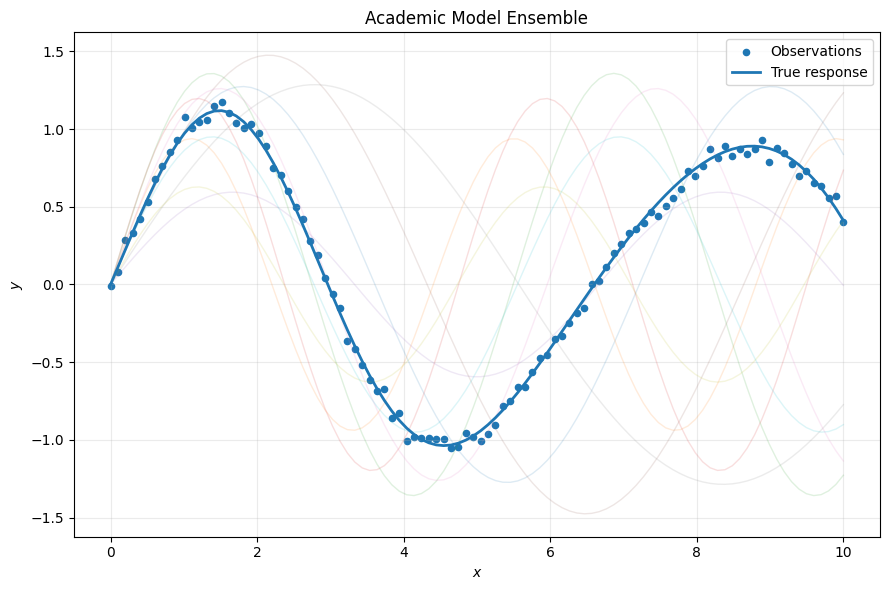

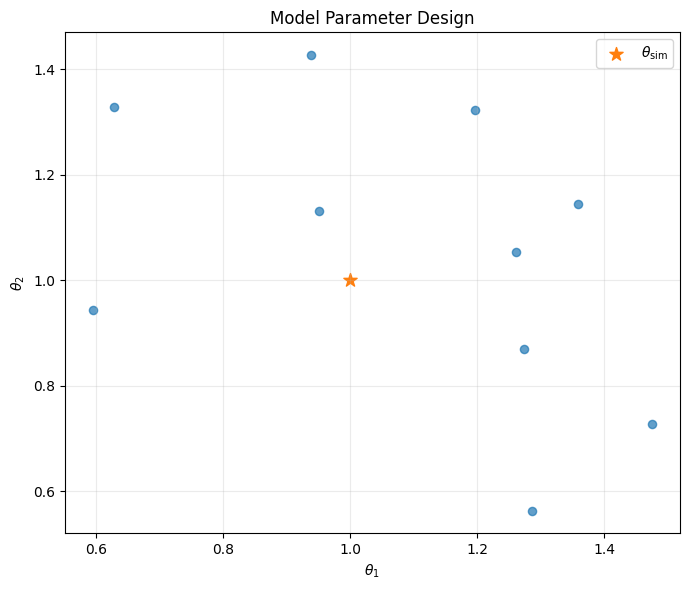


Generated files:

modelData/
  appDomain.txt
  modelPredictions.txt
  thetaVals.txt

observationData/
  appDomain.txt
  observationData.txt

Model ensemble:
  Number of model runs: 10
  Points per model run: 100
  Total model points:   1000

File shapes:
  model x:       (1000,)
  model y:       (1000,)
  theta values:  (1000, 2)
  observed x:    (100,)
  observed y:    (100,)

True nominal parameters:
  theta_1 = 1.0000
  theta_2 = 1.0000


In [16]:
import os
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# Reproducibility
# ============================================================
rng = np.random.default_rng(42)


# ============================================================
# Directories
# ============================================================
model_dir = "modelData"
observation_dir = "observationData"

os.makedirs(model_dir, exist_ok=True)
os.makedirs(observation_dir, exist_ok=True)


# ============================================================
# Application domain
# ============================================================
x = np.linspace(0.0, 10.0, 100)


# ============================================================
# Academic model
#
# y(x, theta) = theta_1 * sin(theta_2 * x)
#
# theta_1 controls amplitude
# theta_2 controls frequency
# ============================================================
def simulator(x, theta_1, theta_2):
    return theta_1 * np.sin(theta_2 * x)


# ============================================================
# Parameter space
#
# Generate MANY model parameter combinations so that the
# calibration/emulator can learn sensitivity to theta_1 and
# theta_2.
# ============================================================

n_model_runs = 10

theta_1_samples = rng.uniform(
    0.5,
    1.5,
    size=n_model_runs
)

theta_2_samples = rng.uniform(
    0.5,
    1.5,
    size=n_model_runs
)

theta_samples = np.column_stack([
    theta_1_samples,
    theta_2_samples
])


# ============================================================
# TRUE nominal parameter vector
#
# This represents the parameter values of the model that
# generated the observations BEFORE parameter correction.
#
# You can choose this independently of the model-design
# samples.
# ============================================================

theta_sim = np.array([
    1.0,
    1.0
])


# ============================================================
# TRUE PARAMETER CORRECTION
#
# This is the ONLY source of systematic discrepancy.
# ============================================================

kappa_1_true = (
    0.15 * np.sin(2.0 * np.pi * x / 10.0)
)

kappa_2_true = (
    0.10 * np.cos(np.pi * x / 10.0)
)


# ============================================================
# TRUE PHYSICAL PARAMETERS
# ============================================================

theta_1_true = (
    theta_sim[0] + kappa_1_true
)

theta_2_true = (
    theta_sim[1] + kappa_2_true
)


# ============================================================
# Generate the model ensemble
#
# Every parameter pair gets evaluated over the entire
# application domain.
# ============================================================

model_x = []
model_predictions = []
model_theta = []

for theta_1, theta_2 in theta_samples:

    y_model = simulator(
        x,
        theta_1,
        theta_2
    )

    model_x.append(x)
    model_predictions.append(y_model)

    model_theta.append(
        np.column_stack([
            np.full_like(x, theta_1),
            np.full_like(x, theta_2)
        ])
    )


# Convert lists into arrays
model_x = np.concatenate(model_x)
model_predictions = np.concatenate(model_predictions)
model_theta = np.vstack(model_theta)


# ============================================================
# Generate synthetic observations
#
# IMPORTANT:
#
# The observations are generated using the TRUE parameter
# correction, not from the model ensemble.
# ============================================================

true_response = simulator(
    x,
    theta_1_true,
    theta_2_true
)


# Observation noise
sigma_obs = 0.05

observation_noise = rng.normal(
    0.0,
    sigma_obs,
    size=x.shape
)

observation_data = (
    true_response + observation_noise
)


# ============================================================
# Write MODEL data
# ============================================================

np.savetxt(
    os.path.join(model_dir, "appDomain.txt"),
    model_x
)

np.savetxt(
    os.path.join(model_dir, "modelPredictions.txt"),
    model_predictions
)

np.savetxt(
    os.path.join(model_dir, "thetaVals.txt"),
    model_theta
)


# ============================================================
# Write OBSERVATION data
# ============================================================

np.savetxt(
    os.path.join(observation_dir, "appDomain.txt"),
    x
)

np.savetxt(
    os.path.join(observation_dir, "observationData.txt"),
    observation_data
)


# ============================================================
# Plot the model ensemble
# ============================================================

fig, ax = plt.subplots(figsize=(9, 6))

for i in range(n_model_runs):

    start = i * len(x)
    end = (i + 1) * len(x)

    ax.plot(
        x,
        model_predictions[start:end],
        alpha=0.15,
        linewidth=1
    )


ax.scatter(
    x,
    observation_data,
    s=20,
    label="Observations"
)

ax.plot(
    x,
    true_response,
    linewidth=2,
    label="True response"
)

ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
ax.set_title("Academic Model Ensemble")
ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()


# ============================================================
# Plot the parameter design
# ============================================================

fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(
    theta_1_samples,
    theta_2_samples,
    s=35,
    alpha=0.7
)

ax.scatter(
    theta_sim[0],
    theta_sim[1],
    s=100,
    marker="*",
    label=r"$\theta_{\mathrm{sim}}$"
)

ax.set_xlabel(r"$\theta_1$")
ax.set_ylabel(r"$\theta_2$")
ax.set_title("Model Parameter Design")
ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()


# ============================================================
# Verify output
# ============================================================

print("\nGenerated files:")

print("\nmodelData/")
print("  appDomain.txt")
print("  modelPredictions.txt")
print("  thetaVals.txt")

print("\nobservationData/")
print("  appDomain.txt")
print("  observationData.txt")

print("\nModel ensemble:")
print(f"  Number of model runs: {n_model_runs}")
print(f"  Points per model run: {len(x)}")
print(f"  Total model points:   {len(model_predictions)}")

print("\nFile shapes:")
print(f"  model x:       {model_x.shape}")
print(f"  model y:       {model_predictions.shape}")
print(f"  theta values:  {model_theta.shape}")
print(f"  observed x:    {x.shape}")
print(f"  observed y:    {observation_data.shape}")

print("\nTrue nominal parameters:")
print(f"  theta_1 = {theta_sim[0]:.4f}")
print(f"  theta_2 = {theta_sim[1]:.4f}")